# Model-Level Mutation Testing (SuT: `MnistCNN`)

In this exercise, we explore **model-level mutation testing** for deep neural networks. Unlike traditional mutation testing that modifies source code, model-level mutation introduces perturbations directly to the trained model's weights, neurons, or layers.

This approach helps evaluate how robust a DNN is to internal perturbations and how well a test suite can detect behavioral changes caused by model mutations.

In [1]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [2]:
# Load pre-saved MNIST model
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [3]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


In [4]:
from neuron_coverages import neuron_coverage, top_k_neuron_coverage
from mnist_instrumentation import forward_and_capture_relu
import torch.nn as nn
import copy

## Mutation Operators

We implement the following mutation operators based on the **DeepMutation** framework:

| Operator | Level | Description |
|----------|-------|-------------|
| **Gaussian Fuzzing (GF)** | Weight | Fuzz selected weights using a Gaussian distribution |
| **Weight Shuffling (WS)** | Neuron | Shuffle selected weights within a neuron |
| **Neuron Effect Block (NEB)** | Neuron | Block the effect of a neuron on subsequent layers |
| **Neuron Activation Inverse (NAI)** | Neuron | Invert the activation status of a neuron |
| **Neuron Switch (NS)** | Neuron | Switch two neurons within the same layer |
| **Layer Deactivation (LD)** | Layer | Deactivate the effects of an entire layer |
| **Layer Addition (LAm)** | Layer | Add a new layer to the neural network |
| **Activation Function Removal (AFRm)** | Layer | Remove activation functions from a layer |

> **Reference**: Ma, Lei, et al. *"DeepMutation: Mutation testing of deep learning systems."* IEEE ISSRE, 2018.

### Gaussian Fuzzing (GF)

**Level**: Weight

Adds Gaussian noise to selected weights. Given a weight value $w$, the mutated value is sampled from $N(w, \sigma^2)$, where $\sigma$ is a configurable parameter. Most fuzzed values stay within $[w-3\sigma, w+3\sigma]$ (99.7% probability).

In [5]:
def GF_mutation(model, sigma=0.1, mutation_ratio=0.1):
    """
    Gaussian Fuzzing (GF) - Weight-level mutation operator.
    
    Mutates selected weights by adding Gaussian noise N(0, σ²).
    The fuzzed weight w' = w + noise, where noise ~ N(0, σ²).
    
    Args:
        model: Original PyTorch model
        sigma: Standard deviation of Gaussian noise (default: 0.1)
        mutation_ratio: Fraction of weights to mutate (default: 0.1 = 10%)
    
    Returns:
        mutant: Mutated copy of the model
    """
    # Create a deep copy to avoid modifying the original model
    mutant = copy.deepcopy(model)
    
    with torch.no_grad():
        for name, param in mutant.named_parameters():
            if 'weight' in name:  # Only mutate weights, not biases
                # Create mutation mask (select random weights to mutate)
                mask = torch.rand_like(param) < mutation_ratio
                
                # Generate Gaussian noise
                noise = torch.randn_like(param) * sigma
                
                # Apply noise only to selected weights
                param.add_(noise * mask.float())
    
    return mutant


# Create mutant with GF
mutant_model = GF_mutation(model, sigma=0.1, mutation_ratio=0.1)

# Compare weights (first layer)
print('Weight comparison (first layer):')
orig_weights = list(model.parameters())[0]
mut_weights = list(mutant_model.parameters())[0]
diff = (orig_weights - mut_weights).abs()

n_mutated = (diff > 0).sum().item()
n_total = diff.numel()

print(f'  Total weights: {n_total}')
print(f'  Mutated weights: {n_mutated} ({100*n_mutated/n_total:.1f}%)')
print(f'  Mean difference (mutated only): {diff[diff > 0].mean():.4f}')
print(f'  Max difference: {diff.max():.4f}')

# Show example of actual weight changes
print(f'\nExample weight changes (first 5 mutated):')
mutated_idx = (diff > 0).flatten().nonzero()[:5]
for idx in mutated_idx:
    i = idx.item()
    orig_val = orig_weights.flatten()[i].item()
    mut_val = mut_weights.flatten()[i].item()
    print(f'  Weight[{i}]: {orig_val:.4f} → {mut_val:.4f} (Δ={mut_val-orig_val:+.4f})')

Weight comparison (first layer):
  Total weights: 72
  Mutated weights: 3 (4.2%)
  Mean difference (mutated only): 0.1276
  Max difference: 0.2070

Example weight changes (first 5 mutated):
  Weight[63]: 0.4159 → 0.4455 (Δ=+0.0296)
  Weight[68]: -0.0921 → 0.1149 (Δ=+0.2070)
  Weight[71]: -0.1942 → -0.3402 (Δ=-0.1460)


### Weight Shuffling (WS)

**Level**: Neuron

Randomly selects a neuron and shuffles the weights of its incoming connections. The weight values remain the same, but their positions are reordered, changing how the neuron combines inputs from the previous layer.

In [6]:
def WS_mutation(model, mutation_ratio=0.1):
    """
    Weight Shuffling (WS) - Neuron-level mutation operator.
    
    Randomly selects neurons and shuffles their incoming connection weights.
    This changes the neuron's output without altering the weight values themselves.
    
    Args:
        model: Original PyTorch model
        mutation_ratio: Fraction of neurons to mutate (default: 0.1 = 10%)
    
    Returns:
        mutant: Mutated copy of the model
    """
    mutant = copy.deepcopy(model)
    
    with torch.no_grad():
        for name, param in mutant.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                # For Conv2d: shape is [out_channels, in_channels, H, W]
                # For Linear: shape is [out_features, in_features]
                # Each row represents a neuron's incoming weights
                
                num_neurons = param.shape[0]
                num_to_mutate = max(1, int(num_neurons * mutation_ratio))
                
                # Randomly select neurons to mutate
                neurons_to_mutate = torch.randperm(num_neurons)[:num_to_mutate]
                
                for neuron_idx in neurons_to_mutate:
                    # Get the weights for this neuron and flatten
                    weights = param[neuron_idx].flatten()
                    
                    # Shuffle the weights
                    shuffled_idx = torch.randperm(weights.numel())
                    shuffled_weights = weights[shuffled_idx]
                    
                    # Assign back
                    param[neuron_idx] = shuffled_weights.view(param[neuron_idx].shape)
    
    return mutant


# Test the WS operator
mutant_ws = WS_mutation(model, mutation_ratio=0.1)

# Compare weights (first layer)
print('Weight Shuffling comparison (first layer):')
orig_weights = list(model.parameters())[0]
mut_weights = list(mutant_ws.parameters())[0]

# Check if weight values are preserved (just reordered)
orig_sorted = orig_weights.flatten().sort()[0]
mut_sorted = mut_weights.flatten().sort()[0]
values_preserved = torch.allclose(orig_sorted, mut_sorted)

# Check how many neurons were affected
neurons_changed = 0
for i in range(orig_weights.shape[0]):
    if not torch.equal(orig_weights[i], mut_weights[i]):
        neurons_changed += 1

print(f'  Total neurons: {orig_weights.shape[0]}')
print(f'  Mutated neurons: {neurons_changed} ({100*neurons_changed/orig_weights.shape[0]:.1f}%)')
print(f'  Weight values preserved (just reordered): {values_preserved}')

# Show example of a neuron that was actually shuffled (random selection may skip neuron 0)
example_idx = next(
    (i for i in range(orig_weights.shape[0]) if not torch.equal(orig_weights[i], mut_weights[i])),
    None,
)
if example_idx is not None:
    print(f'\nExample shuffled neuron (neuron {example_idx}, first 10 weights):')
    print(f'  Original: {orig_weights[example_idx].flatten()[:10].tolist()}')
    print(f'  Shuffled: {mut_weights[example_idx].flatten()[:10].tolist()}')
else:
    print(
        '\nNo first-layer neuron differs from the original '
        '(possible if a shuffle happened to match the original order).'
    )

Weight Shuffling comparison (first layer):
  Total neurons: 8
  Mutated neurons: 1 (12.5%)
  Weight values preserved (just reordered): True

Example shuffled neuron (neuron 4, first 10 weights):
  Original: [-0.12548589706420898, -0.07378759980201721, 0.009601250290870667, 0.4340929090976715, 0.12663821876049042, 0.2856881618499756, 0.08870010823011398, 0.5001137852668762, 0.003207175526767969]
  Shuffled: [0.5001137852668762, -0.07378759980201721, 0.4340929090976715, 0.12663821876049042, 0.003207175526767969, -0.12548589706420898, 0.009601250290870667, 0.08870010823011398, 0.2856881618499756]


### Neuron Effect Block (NEB)

**Level**: Neuron

Blocks a neuron's effect on subsequent layers by setting its outgoing connection weights to zero. This removes the neuron's contribution to the final decision without deleting it from the network.

In [7]:
def NEB_mutation(model, mutation_ratio=0.1):
    """
    Neuron Effect Block (NEB) - Neuron-level mutation operator.

    For randomly selected output units (rows of each Conv/Linear weight tensor),
    sets that unit's incoming weights and the matching bias entry to zero.
    Pre-activation is then always 0, so after ReLU that unit's activation is
    always 0 (no input-dependent signal to later layers).

    Args:
        model: Original PyTorch model
        mutation_ratio: Fraction of output units to block per layer (default: 0.1)

    Returns:
        mutant: Mutated copy of the model
    """
    mutant = copy.deepcopy(model)

    with torch.no_grad():
        named = dict(mutant.named_parameters())

        for name, param in named.items():
            if 'weight' in name and param.dim() >= 2:
                num_neurons = param.shape[0]
                num_to_block = max(1, int(num_neurons * mutation_ratio))
                neurons_to_block = torch.randperm(num_neurons)[:num_to_block]

                bias_name = name.replace('.weight', '.bias')
                bias_param = named.get(bias_name)

                for neuron_idx in neurons_to_block:
                    param[neuron_idx] = 0.0
                    if (
                        bias_param is not None
                        and bias_param.dim() >= 1
                        and bias_param.shape[0] == num_neurons
                    ):
                        bias_param[neuron_idx] = 0.0

    return mutant


# Test the NEB operator
mutant_neb = NEB_mutation(model, mutation_ratio=0.1)

print('Neuron Effect Block comparison (first layer):')
orig_weights = list(model.parameters())[0]
mut_weights = list(mutant_neb.parameters())[0]

# Count blocked neurons (all weights are zero)
blocked_neurons = 0
for i in range(mut_weights.shape[0]):
    if (mut_weights[i] == 0).all():
        blocked_neurons += 1

print(f'  Total neurons: {orig_weights.shape[0]}')
print(f'  Blocked neurons: {blocked_neurons} ({100*blocked_neurons/orig_weights.shape[0]:.1f}%)')

# Show example of a neuron that was actually blocked (random selection may skip neuron 0)
example_idx = next(
    (i for i in range(mut_weights.shape[0]) if (mut_weights[i] == 0).all()),
    None,
)
if example_idx is not None:
    on = dict(model.named_parameters())
    mn = dict(mutant_neb.named_parameters())
    print(f'\nExample blocked output unit (channel {example_idx}, conv1):')
    print(f'  Original weight sum: {orig_weights[example_idx].sum():.4f}')
    print(f'  Mutant weight sum:   {mut_weights[example_idx].sum():.4f}')
    if 'conv1.bias' in on:
        print(f'  Original bias: {on["conv1.bias"][example_idx].item():.4f}')
        print(f'  Mutant bias:   {mn["conv1.bias"][example_idx].item():.4f}')
        print('  → pre-ReLU is 0, so this channel’s activation is always 0.')
else:
    print('\nNo fully zeroed-out neuron in the first layer (unexpected after NEB).')


Neuron Effect Block comparison (first layer):
  Total neurons: 8
  Blocked neurons: 1 (12.5%)

Example blocked output unit (channel 0, conv1):
  Original weight sum: 1.3832
  Mutant weight sum:   0.0000
  Original bias: -0.1128
  Mutant bias:   0.0000
  → pre-ReLU is 0, so this channel’s activation is always 0.


### Neuron Activation Inverse (NAI)

**Level**: Neuron

Inverts the activation status of a neuron by negating its output before the activation function. For ReLU, this can change an active neuron (positive output) to inactive (negative → 0), or vice versa.

In [8]:
def NAI_mutation(model, mutation_ratio=0.1):
    """
    Neuron Activation Inverse (NAI) - Neuron-level mutation operator.

    For selected output units, negates that unit's weight row and matching bias
    so pre-activation z becomes -z (same as flipping the affine output before
    ReLU). Weight-only negation would give -w·x + b, not -(w·x + b).

    Args:
        model: Original PyTorch model
        mutation_ratio: Fraction of neurons to invert per layer (default: 0.1)

    Returns:
        mutant: Mutated copy of the model
    """
    mutant = copy.deepcopy(model)

    with torch.no_grad():
        named = dict(mutant.named_parameters())
        for name, param in named.items():
            if 'weight' in name and param.dim() >= 2:
                num_neurons = param.shape[0]
                num_to_invert = max(1, int(num_neurons * mutation_ratio))
                neurons_to_invert = torch.randperm(num_neurons)[:num_to_invert]

                bias_name = name.replace('.weight', '.bias')
                bias_param = named.get(bias_name)

                for neuron_idx in neurons_to_invert:
                    param[neuron_idx] = -param[neuron_idx]
                    if (
                        bias_param is not None
                        and bias_param.dim() >= 1
                        and bias_param.shape[0] == num_neurons
                    ):
                        bias_param[neuron_idx] = -bias_param[neuron_idx]

    return mutant


# Test the NAI operator
mutant_nai = NAI_mutation(model, mutation_ratio=0.1)

print('Neuron Activation Inverse comparison (first layer):')
orig_weights = list(model.parameters())[0]
mut_weights = list(mutant_nai.parameters())[0]

on = dict(model.named_parameters())
mn = dict(mutant_nai.named_parameters())
ob, mb = on.get('conv1.bias'), mn.get('conv1.bias')

# Count units where both W and b are negated (full z -> -z for conv1)
inverted_neurons = 0
for i in range(orig_weights.shape[0]):
    w_ok = torch.allclose(orig_weights[i], -mut_weights[i])
    b_ok = ob is None or torch.allclose(ob[i], -mb[i])
    if w_ok and b_ok:
        inverted_neurons += 1

print(f'  Total neurons: {orig_weights.shape[0]}')
print(f'  Inverted neurons: {inverted_neurons} ({100*inverted_neurons/orig_weights.shape[0]:.1f}%)')

# Show example (first fully inverted unit on conv1)
print(f'\nExample inverted output unit (conv1, first match):')
for i in range(orig_weights.shape[0]):
    w_ok = torch.allclose(orig_weights[i], -mut_weights[i])
    b_ok = ob is None or torch.allclose(ob[i], -mb[i])
    if w_ok and b_ok:
        print(f'  Channel {i} - Original W[0]: {orig_weights[i].flatten()[0]:.4f}')
        print(f'  Channel {i} - Mutant W[0]:   {mut_weights[i].flatten()[0]:.4f}')
        if ob is not None:
            print(f'  Channel {i} - Original bias: {ob[i].item():.4f}')
            print(f'  Channel {i} - Mutant bias:   {mb[i].item():.4f}')
        break


Neuron Activation Inverse comparison (first layer):
  Total neurons: 8
  Inverted neurons: 1 (12.5%)

Example inverted output unit (conv1, first match):
  Channel 1 - Original W[0]: -0.1421
  Channel 1 - Mutant W[0]:   0.1421
  Channel 1 - Original bias: -0.1404
  Channel 1 - Mutant bias:   0.1404


### Neuron Switch (NS)

**Level**: Neuron

Swaps two **output units** in a layer (incoming: that layer’s weight rows + biases). To keep the network consistent, the **next** layer’s weights that **read** those outputs are updated too (Conv input-channel slices, `Linear` columns, or channel-aligned column blocks into `fc1`). The notebook implements this for the exercise **`MnistCNN`** (`conv1`↔`conv2`↔`fc1`↔`fc2`).

In [9]:
def NS_mutation(model, num_switches=1, include_higher_stages=True):
    """
    Neuron Switch (NS) — swap two output units in a layer *and* fix the next layer.

    Incoming (current layer L): swap output rows of W_L and the matching bias entries
    so channels / neurons i and j exchange roles.

    Outgoing (next layer L+1): swap how L+1 reads those outputs:
      - Conv: swap slices [:, i] and [:, j] on in_channels (all output filters).
      - Linear: swap columns i and j (every output neuron).
      - conv2 -> flatten -> fc1: fc1 columns are channel-major blocks of H*W; swap blocks.

    Expects an MnistCNN-like module with attributes conv1, conv2, fc1, fc2.
    fc2 has no downstream layer; only incoming (row + bias) swap.

    Args:
        model: Original PyTorch model (MnistCNN in this exercise).
        num_switches: Number of random pair swaps per stage (default: 1).
        include_higher_stages: If True (default), also run conv2↔fc1, fc1↔fc2, and fc2
            swaps. Those later steps rewrite conv2's *output* rows, which breaks
            identities like mut.conv2[:, i] == orig.conv2[:, j] from the conv1 stage.
            Set False to only perform the conv1 output swap + conv2 in_channel fix
            (useful for verifying that first link).

    Returns:
        mutant: Deep copy with consistent channel/neuron permutations.
    """
    mutant = copy.deepcopy(model)

    def swap_rows(tensor, i, j):
        """Swap 2D+ slices along dim 0 (e.g. output channels / output neurons)."""
        tmp = tensor[i].clone()
        tensor[i] = tensor[j]
        tensor[j] = tmp

    def swap_bias_1d(bias, i, j):
        if bias is None:
            return
        tmp = bias[i].clone()
        bias[i] = bias[j]
        bias[j] = tmp

    def swap_conv_in_channels(weight, i, j):
        """
        Next Conv layer: weight [out_c, in_c, kh, kw].
        Exchange *incoming* connections from previous-layer channels i and j for every out filter.
        """
        tmp = weight[:, i].clone()
        weight[:, i] = weight[:, j]
        weight[:, j] = tmp

    def swap_linear_in_columns(weight, i, j):
        """Next Linear: weight [out, in] — swap input features i and j for all outputs."""
        tmp = weight[:, i].clone()
        weight[:, i] = weight[:, j]
        weight[:, j] = tmp

    def swap_fc1_blocks_for_conv_channels(weight, i, j, h_spatial, w_spatial):
        """
        [B, C, H, W].view(B, -1) uses channel-major order: each channel occupies H*W columns in fc1.
        """
        block = h_spatial * w_spatial
        s1, e1 = i * block, (i + 1) * block
        s2, e2 = j * block, (j + 1) * block
        tmp = weight[:, s1:e1].clone()
        weight[:, s1:e1] = weight[:, s2:e2]
        weight[:, s2:e2] = tmp

    with torch.no_grad():
        # MnistCNN: 28x28 -> pool -> 14 -> pool -> 7 (spatial size before fc1).
        h_after_c2, w_after_c2 = 7, 7

        # conv1 <-> conv2.in_channels
        if hasattr(mutant, "conv1") and hasattr(mutant, "conv2"):
            c = mutant.conv1.out_channels
            if c >= 2:
                for _ in range(num_switches):
                    i, j = torch.randperm(c)[:2].tolist()
                    swap_rows(mutant.conv1.weight, i, j)
                    swap_bias_1d(mutant.conv1.bias, i, j)
                    swap_conv_in_channels(mutant.conv2.weight, i, j)

        # conv2 <-> fc1 (flattened conv stack) — skipped if only verifying conv1↔conv2
        if include_higher_stages and hasattr(mutant, "conv2") and hasattr(mutant, "fc1"):
            c = mutant.conv2.out_channels
            if c >= 2:
                for _ in range(num_switches):
                    i, j = torch.randperm(c)[:2].tolist()
                    swap_rows(mutant.conv2.weight, i, j)
                    swap_bias_1d(mutant.conv2.bias, i, j)
                    swap_fc1_blocks_for_conv_channels(
                        mutant.fc1.weight, i, j, h_after_c2, w_after_c2
                    )

        # fc1 <-> fc2.in_features
        if include_higher_stages and hasattr(mutant, "fc1") and hasattr(mutant, "fc2"):
            n = mutant.fc1.out_features
            if n >= 2:
                for _ in range(num_switches):
                    i, j = torch.randperm(n)[:2].tolist()
                    swap_rows(mutant.fc1.weight, i, j)
                    swap_bias_1d(mutant.fc1.bias, i, j)
                    swap_linear_in_columns(mutant.fc2.weight, i, j)

        # fc2 logits — no next layer
        if include_higher_stages and hasattr(mutant, "fc2"):
            n = mutant.fc2.out_features
            if n >= 2:
                for _ in range(num_switches):
                    i, j = torch.randperm(n)[:2].tolist()
                    swap_rows(mutant.fc2.weight, i, j)
                    swap_bias_1d(mutant.fc2.bias, i, j)

    return mutant


# Test the NS operator (conv1↔conv2 only so conv2 slice checks stay valid)
mutant_ns = NS_mutation(model, num_switches=1, include_higher_stages=False)
print(
    'Neuron Switch (conv1↔conv2 only): include_higher_stages=False so later stages '
    'do not re-randomize conv2 output rows and break mut[:,i]==orig[:,j]. '
    'Use include_higher_stages=True for the full MnistCNN NS.\n'
)

print('Neuron Switch comparison (first layer conv1):')
orig_weights = model.conv1.weight
mut_weights = mutant_ns.conv1.weight

# Detect a pair whose weight rows were cross-swapped
switched_pairs = []
for i in range(orig_weights.shape[0]):
    for j in range(i + 1, orig_weights.shape[0]):
        if torch.equal(orig_weights[i], mut_weights[j]) and torch.equal(
            orig_weights[j], mut_weights[i]
        ):
            switched_pairs.append((i, j))

print(f'  Total conv1 output channels: {orig_weights.shape[0]}')
print(f'  Switched pairs (weight rows): {switched_pairs}')

if switched_pairs:
    i, j = switched_pairs[0]
    # i,j index conv1 *output channels* (two filters / neurons in that layer).
    # conv1: swap their *incoming* params (weight rows + bias) — what builds each channel.
    # conv2: the same edges are conv1 *outgoing*; on conv2.weight they are *incoming*
    #   along in_channels, so we swap slices [:, i] and [:, j] for every conv2 filter.
    ow, mw = orig_weights, mut_weights
    ob, mb = model.conv1.bias, mutant_ns.conv1.bias
    oc2, mc2 = model.conv2.weight, mutant_ns.conv2.weight

    print(
        '\n(What this example shows: conv1 output channels i and j are swapped. '
        'On conv1 that is an *incoming* row+bias swap; on conv2 the same links are '
        '*outgoing* from conv1 but *incoming* as conv2.weight[:, i] vs [:, j].)\n'
    )

    print(
        f'=== conv1 — incoming to the two swapped output channels {i} <-> {j} '
        f'(weight rows + bias) ==='
    )
    for ch in (i, j):
        print(f'\n  Output channel {ch}: before mutation → after mutation')
        print(f'    W row sum: {ow[ch].sum():.6f} → {mw[ch].sum():.6f}')
        if ob is not None:
            print(f'    bias: {ob[ch].item():.6f} → {mb[ch].item():.6f}')

    print('\n  Consistency (cross-swap): mut row i should be orig row j, etc.')
    print(f'    torch.equal(mut.W[{i}], orig.W[{j}]): {torch.equal(mw[i], ow[j])}')
    print(f'    torch.equal(mut.W[{j}], orig.W[{i}]): {torch.equal(mw[j], ow[i])}')
    if ob is not None:
        print(f'    mut.b[{i}] vs orig.b[{j}]: {torch.allclose(mb[i], ob[j])}')
        print(f'    mut.b[{j}] vs orig.b[{i}]: {torch.allclose(mb[j], ob[i])}')

    print(
        f'\n=== conv2 — same edges, *incoming* view: swap in_channel slices '
        f'{i} <-> {j} (conv1 would call these *outgoing* from channels {i},{j}) ==='
    )
    print(f'  Full slice [:, {i}]  sum: orig {oc2[:, i].sum():.6f} → mut {mc2[:, i].sum():.6f}')
    print(f'  Full slice [:, {j}]  sum: orig {oc2[:, j].sum():.6f} → mut {mc2[:, j].sum():.6f}')
    print(f'  mut[:, {i}] == orig[:, {j}] (all filters): {torch.equal(mc2[:, i], oc2[:, j])}')
    print(f'  mut[:, {j}] == orig[:, {i}] (all filters): {torch.equal(mc2[:, j], oc2[:, i])}')


Neuron Switch (conv1↔conv2 only): include_higher_stages=False so later stages do not re-randomize conv2 output rows and break mut[:,i]==orig[:,j]. Use include_higher_stages=True for the full MnistCNN NS.

Neuron Switch comparison (first layer conv1):
  Total conv1 output channels: 8
  Switched pairs (weight rows): [(3, 6)]

(What this example shows: conv1 output channels i and j are swapped. On conv1 that is an *incoming* row+bias swap; on conv2 the same links are *outgoing* from conv1 but *incoming* as conv2.weight[:, i] vs [:, j].)

=== conv1 — incoming to the two swapped output channels 3 <-> 6 (weight rows + bias) ===

  Output channel 3: before mutation → after mutation
    W row sum: -0.950113 → 1.698755
    bias: 0.348455 → -0.001618

  Output channel 6: before mutation → after mutation
    W row sum: 1.698755 → -0.950113
    bias: -0.001618 → 0.348455

  Consistency (cross-swap): mut row i should be orig row j, etc.
    torch.equal(mut.W[3], orig.W[6]): True
    torch.equal(mut

### Layer Deactivation (LD)

**Level**: Layer

Removes a layer's transformation by making it an identity function (output = input). Only applicable to layers where input and output shapes are consistent, to avoid breaking the network structure.

In [10]:
def LD_mutation(model, layer_name=None):
    """
    Layer Deactivation (LD) - Layer-level mutation operator.
    
    Makes a layer act as identity by setting weights to identity matrix
    and biases to zero. Only works for layers with matching input/output shapes.
    
    Args:
        model: Original PyTorch model
        layer_name: Name of layer to deactivate (if None, selects randomly)
    
    Returns:
        mutant: Mutated copy of the model
    """
    mutant = copy.deepcopy(model)
    
    # Find eligible layers (where we can create identity)
    eligible_layers = []
    for name, module in mutant.named_modules():
        if isinstance(module, nn.Linear) and module.in_features == module.out_features:
            eligible_layers.append((name, module))
    
    if not eligible_layers:
        print("No eligible layers for LD mutation (need matching in/out dimensions)")
        return mutant
    
    # Select layer to deactivate
    if layer_name:
        target = [(n, m) for n, m in eligible_layers if n == layer_name]
        if not target:
            print(f"Layer {layer_name} not eligible")
            return mutant
        name, module = target[0]
    else:
        name, module = eligible_layers[torch.randint(len(eligible_layers), (1,)).item()]
    
    with torch.no_grad():
        # Set weights to identity matrix
        module.weight.copy_(torch.eye(module.in_features, device=module.weight.device))
        # Set biases to zero
        if module.bias is not None:
            module.bias.zero_()
    
    print(f"Deactivated layer: {name}")
    return mutant


# Test the LD operator
print('Layer Deactivation test:')
mutant_ld = LD_mutation(model)

# Note: This may not find eligible layers in MnistCNN if no Linear layer has matching in/out


Layer Deactivation test:
No eligible layers for LD mutation (need matching in/out dimensions)


### Layer Addition (LAm)

**Level**: Layer

Duplicates an existing layer and inserts the copy after the original. The new layer initially performs the same transformation. Only applicable where input/output shapes match to preserve network structure.

In [11]:
def LAm_mutation(model, layer_name=None):
    """
    Layer Addition (LAm) - Layer-level mutation operator.
    
    Duplicates a layer by adding an identity layer after it.
    Only works for layers with matching input/output shapes.
    
    Note: This is a simplified version that modifies weights rather than
    actually inserting a new layer (which would require model restructuring).
    
    Args:
        model: Original PyTorch model
        layer_name: Name of layer to duplicate effect (if None, selects randomly)
    
    Returns:
        mutant: Mutated copy of the model
    """
    mutant = copy.deepcopy(model)
    
    # Find eligible layers
    eligible_layers = []
    for name, module in mutant.named_modules():
        if isinstance(module, nn.Linear) and module.in_features == module.out_features:
            eligible_layers.append((name, module))
    
    if not eligible_layers:
        print("No eligible layers for LAm mutation (need matching in/out dimensions)")
        return mutant
    
    # Select layer to "duplicate" (we simulate by applying transform twice via weight modification)
    if layer_name:
        target = [(n, m) for n, m in eligible_layers if n == layer_name]
        if not target:
            print(f"Layer {layer_name} not eligible")
            return mutant
        name, module = target[0]
    else:
        name, module = eligible_layers[torch.randint(len(eligible_layers), (1,)).item()]
    
    with torch.no_grad():
        # Simulate layer duplication by squaring the weight matrix (W' = W @ W)
        # This makes the layer apply its transformation twice
        module.weight.copy_(module.weight @ module.weight)
    
    print(f"Duplicated layer effect: {name}")
    return mutant


# Test the LAm operator
print('Layer Addition test:')
mutant_lam = LAm_mutation(model)


Layer Addition test:
No eligible layers for LAm mutation (need matching in/out dimensions)


### Activation Function Removal (AFRm)

**Level**: Layer

Skips ReLU after selected affine blocks so **negative pre-activations are kept** (linear pass-through). Weights are unchanged; the notebook uses an `MnistCNN`-shaped wrapper and a copied `forward` (ReLU is applied in `forward`, not as `nn.ReLU` submodules in the original class).

In [12]:
import torch.nn.functional as F

class MnistCNN_AFRm(nn.Module):
    """
    Same layers as MnistCNN but ReLU after chosen blocks can be turned off.
    Weights live on the copied submodules (see AFRm_mutation).
    """

    def __init__(self, inner):
        super().__init__()
        self.conv1 = inner.conv1
        self.conv2 = inner.conv2
        self.fc1 = inner.fc1
        self.fc2 = inner.fc2
        self.no_relu_after_conv1 = False
        self.no_relu_after_conv2 = False
        self.no_relu_after_fc1 = False

    def forward(self, x):
        x = self.conv1(x)
        if not self.no_relu_after_conv1:
            x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        if not self.no_relu_after_conv2:
            x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        if not self.no_relu_after_fc1:
            x = F.relu(x)
        return self.fc2(x)


def AFRm_mutation(model, remove_relu_after=("conv1",), layer_indices=None):
    """
    Activation Function Removal (AFRm) — skip ReLU after selected affine blocks.

    Negative pre-activations then flow to the next op (pool / next layer) instead
    of being clipped to 0. Implemented for MnistCNN-like modules (conv1, conv2,
    fc1, fc2) by wrapping a deep copy in MnistCNN_AFRm.

    Args:
        model: Original PyTorch module (MnistCNN in this exercise).
        remove_relu_after: Which blocks to make linear after, e.g. ("conv1",),
            ("conv2",), ("fc1",), or several.
        layer_indices: Deprecated alias — if set, maps 0→conv1, 1→conv2, 2→fc1.

    Returns:
        mutant: nn.Module (MnistCNN_AFRm) with independent parameter tensors.
    """
    if layer_indices is not None:
        key = {0: "conv1", 1: "conv2", 2: "fc1"}
        remove_relu_after = tuple(key[i] for i in layer_indices if i in key)
        if not remove_relu_after:
            remove_relu_after = ("conv1",)

    if not (
        hasattr(model, "conv1")
        and hasattr(model, "conv2")
        and hasattr(model, "fc1")
        and hasattr(model, "fc2")
    ):
        raise TypeError("AFRm_mutation (this notebook) expects MnistCNN-like attributes conv1..fc2.")

    inner = copy.deepcopy(model)
    mutant = MnistCNN_AFRm(inner)
    for name in remove_relu_after:
        if name == "conv1":
            mutant.no_relu_after_conv1 = True
        elif name == "conv2":
            mutant.no_relu_after_conv2 = True
        elif name == "fc1":
            mutant.no_relu_after_fc1 = True
        else:
            raise ValueError(f"Unknown layer tag {name!r}; use conv1, conv2, or fc1.")

    print(f"AFRm: removed ReLU after: {remove_relu_after}")
    return mutant


# Test the AFRm operator (same API: model in → mutant out)
print("Activation Function Removal test:")
mutant_afrm = AFRm_mutation(model, remove_relu_after=("conv1",))

x_try = torch.randn(4, 1, 28, 28)
with torch.no_grad():
    pre1_orig = model.conv1(x_try)
    post1_orig = F.relu(pre1_orig)
    pre1_mut = mutant_afrm.conv1(x_try)

print("\nAfter conv1:")
print(f"  Original: any pre-ReLU negative? {(pre1_orig < 0).any().item()}")
print(f"  Original: any post-ReLU negative? {(post1_orig < 0).any().item()}  (should be False)")
print(
    f"  Mutant:   same conv1 weights, no ReLU — tensor equals pre-ReLU: "
    f"{torch.allclose(pre1_mut, pre1_orig)}"
)
print(f"  Mutant:   any negative values after conv1 block? {(pre1_mut < 0).any().item()}")

ow = model.conv1.weight
mw = mutant_afrm.conv1.weight
print(f"\nWeights unchanged (conv1): {torch.equal(ow, mw)}")


Activation Function Removal test:
AFRm: removed ReLU after: ('conv1',)

After conv1:
  Original: any pre-ReLU negative? True
  Original: any post-ReLU negative? False  (should be False)
  Mutant:   same conv1 weights, no ReLU — tensor equals pre-ReLU: True
  Mutant:   any negative values after conv1 block? True

Weights unchanged (conv1): True


---

## Mutation Score

In this section, we generate a set of MnistCNN mutants and evaluate the mutation score of an arbitrary test suite.

In [13]:
# mutants: list of (name, module). MnistCNN + operators above.
# 10 random draws per high-cardinality op; three AFRm mutants (one ReLU site each).
# LD / LAm are omitted: MnistCNN has no square Linear (in_features == out_features).

mutants = []

# Generate 10 GF mutants.
for i in range(10):
    mutants.append((f"GF_{i}", GF_mutation(model, sigma=0.01, mutation_ratio=0.1)))

# Generate 10 WS mutants.
for i in range(10):
    mutants.append((f"WS_{i}", WS_mutation(model, mutation_ratio=0.01)))

# Generate 10 NEB mutants.
for i in range(10):
    mutants.append((f"NEB_{i}", NEB_mutation(model, mutation_ratio=0.01)))

# Generate 10 NAI mutants.
for i in range(10):
    mutants.append((f"NAI_{i}", NAI_mutation(model, mutation_ratio=0.01)))

# Generate 10 NS mutants.
for i in range(10):
    mutants.append(
        (f"NS_{i}", NS_mutation(model, num_switches=1, include_higher_stages=True))
    )

# Skip LD and LAm.

# Generate 3 AFRm mutants (one ReLU site each).
mutants.append(("AFRm_conv1", AFRm_mutation(model, remove_relu_after=("conv1",))))
mutants.append(("AFRm_conv2", AFRm_mutation(model, remove_relu_after=("conv2",))))
mutants.append(("AFRm_fc1", AFRm_mutation(model, remove_relu_after=("fc1",))))

print(len(mutants), "mutants")

AFRm: removed ReLU after: ('conv1',)
AFRm: removed ReLU after: ('conv2',)
AFRm: removed ReLU after: ('fc1',)
53 mutants


### How we compute mutation score in this exercise

We grow the test suite by taking the **first** images one by one (prefix of the batch). If the mutant’s predicted class differs from the original model’s on **any** of those images, we call that mutant **killed**.

The **mutation score** is $k / |M|$, where $k$ is the number of killed mutants and $|M|$ is how many we generated.

The usual definition divides by non-equivalent mutants only; here we use $|M|$ because that count is hard to know in practice.


[mutation score] suite sizes 1..200, 53 mutants per size — starting ...
[mutation score] size 1/200, score 22.6%
[mutation score] size 10/200, score 83.0%
[mutation score] size 20/200, score 96.2%
[mutation score] size 30/200, score 96.2%
[mutation score] size 40/200, score 96.2%
[mutation score] size 50/200, score 98.1%
[mutation score] size 60/200, score 100.0%
[mutation score] size 70/200, score 100.0%
[mutation score] size 80/200, score 100.0%
[mutation score] size 90/200, score 100.0%
[mutation score] size 100/200, score 100.0%
[mutation score] size 110/200, score 100.0%
[mutation score] size 120/200, score 100.0%
[mutation score] size 130/200, score 100.0%
[mutation score] size 140/200, score 100.0%
[mutation score] size 150/200, score 100.0%
[mutation score] size 160/200, score 100.0%
[mutation score] size 170/200, score 100.0%
[mutation score] size 180/200, score 100.0%
[mutation score] size 190/200, score 100.0%
[mutation score] size 200/200, score 100.0%
[mutation score] done

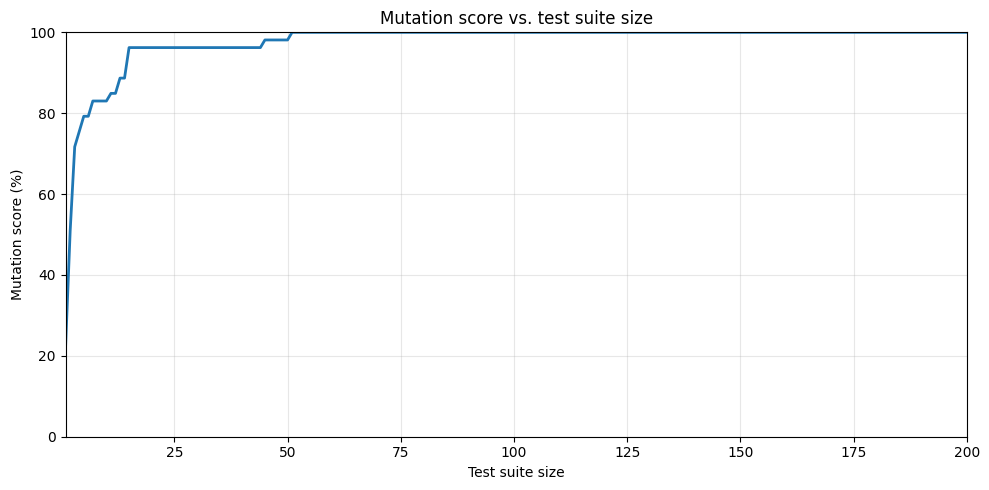

Final mutation score (all 200 tests): 100.0%
At key sizes:
  Size  10: 83.0%
  Size  50: 98.1%
  Size 100: 100.0%
  Size 200: 100.0%


In [14]:
# Mutation score vs. prefix size of the fixed test suite (test_images[:size]).
# A mutant is killed if its argmax predictions differ from the original on ≥1 example in the prefix.

import time

import matplotlib.pyplot as plt

model.eval()
for _tag, m in mutants:
    m.to(device)
    m.eval()


def mutation_score(suite_images):
    if not mutants:
        return 0.0
    batch = suite_images.to(device)
    with torch.no_grad():
        orig_pred = model(batch).argmax(dim=1)
    killed = 0
    for _name, mut in mutants:
        with torch.no_grad():
            mut_pred = mut(batch).argmax(dim=1)
        if not torch.equal(orig_pred, mut_pred):
            killed += 1
    return killed / len(mutants)


max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))
print(
    f"[mutation score] suite sizes 1..{max_size}, {len(mutants)} mutants per size — starting ...",
    flush=True,
)
log_every = max(1, max_size // 20)
scores = []
t0 = time.perf_counter()
for size in batch_sizes:
    scores.append(mutation_score(test_images[:size]))
    if size == 1 or size == max_size or size % log_every == 0:
        print(
            f"[mutation score] size {size}/{max_size}, score {scores[-1]:.1%}",
            flush=True,
        )
elapsed = time.perf_counter() - t0
print(f"[mutation score] done in {elapsed:.1f}s wall time", flush=True)

plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [s * 100 for s in scores], color="tab:blue", linewidth=2)
plt.xlabel("Test suite size")
plt.ylabel("Mutation score (%)")
plt.title("Mutation score vs. test suite size")
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Final mutation score (all {max_size} tests): {scores[-1]:.1%}")
print("At key sizes:")
for size in [10, 50, 100, 200]:
    if size <= max_size:
        print(f"  Size {size:3d}: {scores[size - 1]:.1%}")


### Neuron coverage vs mutation score

For the **same** growing prefixes `test_images[:n]` as in the mutation-score cell, we measure **neuron coverage** on the **original** model (post-ReLU activations via `forward_and_capture_relu`). Each point is one pair $(\text{NC}_n, \text{MS}_n)$; color encodes $n$. Run the mutation-score cell first so `scores` and `batch_sizes` exist.

[neuron coverage] original model, each prefix ...
[neuron coverage] size 1/200, coverage 0.551
[neuron coverage] size 10/200, coverage 0.757
[neuron coverage] size 20/200, coverage 0.795
[neuron coverage] size 30/200, coverage 0.805
[neuron coverage] size 40/200, coverage 0.825
[neuron coverage] size 50/200, coverage 0.846
[neuron coverage] size 60/200, coverage 0.854
[neuron coverage] size 70/200, coverage 0.861
[neuron coverage] size 80/200, coverage 0.875
[neuron coverage] size 90/200, coverage 0.877
[neuron coverage] size 100/200, coverage 0.877
[neuron coverage] size 110/200, coverage 0.880
[neuron coverage] size 120/200, coverage 0.880
[neuron coverage] size 130/200, coverage 0.881
[neuron coverage] size 140/200, coverage 0.889
[neuron coverage] size 150/200, coverage 0.889
[neuron coverage] size 160/200, coverage 0.890
[neuron coverage] size 170/200, coverage 0.890
[neuron coverage] size 180/200, coverage 0.891
[neuron coverage] size 190/200, coverage 0.894
[neuron coverage] siz

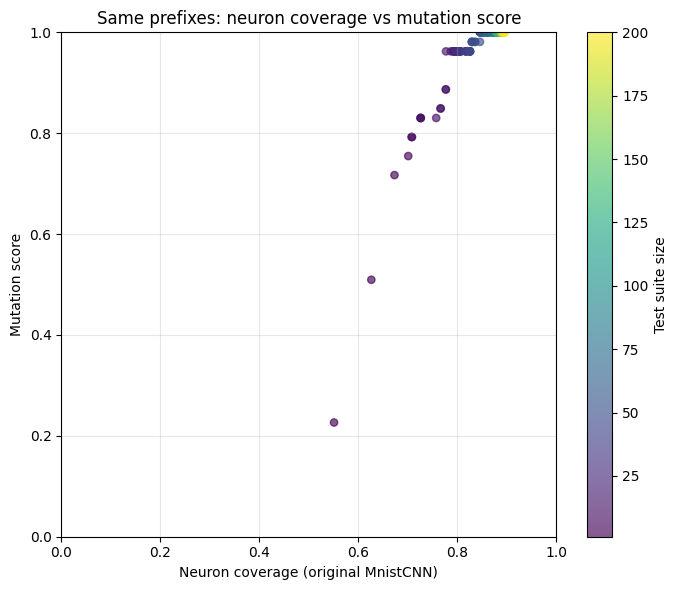

Pearson r (neuron coverage, mutation score): 0.865


In [15]:
# Same prefixes as mutation score: neuron coverage (original model) + scatter vs scores.
# Prerequisite: run the mutation-score cell so `scores`, `batch_sizes`, `max_size` exist.

import time

import matplotlib.pyplot as plt
import numpy as np

model.eval()
nc_scores = []
log_every = max(1, max_size // 20)
print("[neuron coverage] original model, each prefix ...", flush=True)
t0 = time.perf_counter()
for size in batch_sizes:
    batch = test_images[:size].to(device)
    with torch.no_grad():
        _, activations = forward_and_capture_relu(model, batch, to_cpu=True)
    cov, _ = neuron_coverage(activations, threshold=0)
    nc_scores.append(cov)
    if size == 1 or size == max_size or size % log_every == 0:
        print(
            f"[neuron coverage] size {size}/{max_size}, coverage {cov:.3f}",
            flush=True,
        )
print(f"[neuron coverage] done in {time.perf_counter() - t0:.1f}s", flush=True)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    nc_scores,
    scores,
    c=batch_sizes,
    cmap="viridis",
    alpha=0.65,
    s=28,
)
ax.set_xlabel("Neuron coverage (original MnistCNN)")
ax.set_ylabel("Mutation score")
ax.set_title("Same prefixes: neuron coverage vs mutation score")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.colorbar(sc, ax=ax, label="Test suite size")
plt.tight_layout()
plt.show()

r = np.corrcoef(nc_scores, scores)[0, 1]
if np.isnan(r):
    print("Pearson r: undefined (one series is constant).")
else:
    print(f"Pearson r (neuron coverage, mutation score): {r:.3f}")


## ☕ Discussion

Until now, we have explored many structural coverages and mutation testing, whose testing viewpoints differ.

* Structural coverage measures *how much of the code is executed*.
* Mutation testing measures *how well tests can detect artificial (but realistic) faults*.

In other words, coverage is **execution-based**, while mutation testing is **effectiveness-based**. Achieving a high mutation score generally implies high coverage, but high coverage alone does not guarantee effective tests.

---

### Think about

* Why can bugs still exist even with 100% coverage?
* Why is mutation testing considered closer to “real-world” faults?
* Given its high cost, is it practical to apply mutation testing everywhere?
* What would be a reasonable strategy for using mutation testing in practice?

👉 Reflect on what makes a “good test” from these two perspectives.
